In [2]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt
import pandas as pd
import glob
import random
import os

# Función auxiliar para mostrar imágenes en el Notebook sin líos
def mostrar_imagen(img, titulo="Imagen"):
    plt.figure(figsize=(10, 10))
    # YOLO usa BGR (OpenCV), Matplotlib usa RGB. Hay que convertir.
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(titulo)
    plt.axis('off')
    plt.show()

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [ ]:
# RUTA AL MODELO
ruta_modelo = 'runs/models/yolov11n/weights/best.pt'

# Se carga el modelo
model = YOLO(ruta_modelo)

# Se verifica qué clases conoce el modelo
print(f"Modelo cargado exitosamente.")
print(f"Clases detectables: {model.names}")

Modelo cargado exitosamente.
Clases detectables: {0: 'Bee', 1: 'Asian Hornet'}


In [ ]:
# Se ejecuta la validación en el set de TEST
print("Ejecutando validación... esto puede tardar unos segundos.")
metrics = model.val(data='../data/dataset_mini/data.yaml', split='test', plots=True)

# --- Extracción de Métricas Clave ---
print("\n" + "="*30)
print("REPORTE DE MÉTRICAS")
print("="*30)
print(f"mAP50 (Precisión estándar): {metrics.box.map50:.3f}")
print(f"mAP50-95 (Precisión estricta): {metrics.box.map:.3f}")
print(f"Precision Media (P): {metrics.box.mp:.3f}")
print(f"Recall Medio (R): {metrics.box.mr:.3f}")

# Cálculo del F1 Score global aproximado
f1 = 2 * (metrics.box.mp * metrics.box.mr) / (metrics.box.mp + metrics.box.mr + 1e-6)
print(f"F1 Score Global: {f1:.3f}")

Ejecutando validación... esto puede tardar unos segundos.
Ultralytics 8.4.37 🚀 Python-3.11.2 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1080, 8107MiB)


YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.1 ms, read: 66.1±56.0 MB/s, size: 115.4 KB)
val: Scanning /home/jainogue/yolo/data/dataset_mini/test/labels.cache... 400 images, 30 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 400/400 36.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 6.5it/s 3.8s0.1s
                   all        400        744      0.902      0.854      0.917      0.575
                   Bee        215        576      0.914      0.856      0.918      0.629
          Asian Hornet        155        168       0.89      0.851      0.915      0.521
Speed: 0.9ms preprocess, 3.2ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /home/jainogue/yolo/notebooks/runs/detect/val15

REPORTE DE MÉTRICAS
mAP50 (Precisión estándar): 0.917
mAP50-95 (Precisión estricta): 0.575
Precision Media (P): 0.902
Recall Medio (R): 

Analizando gráficos de: runs/detect/val15


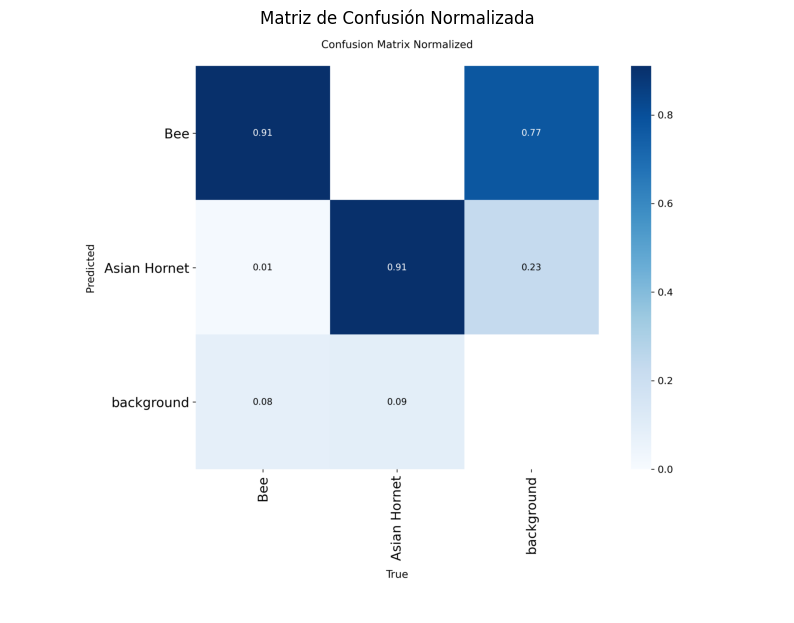

In [ ]:
%matplotlib inline
import pathlib
carpetas_val = sorted(list(pathlib.Path('runs/detect').glob('val*')), key=os.path.getmtime)
ultima_carpeta = carpetas_val[-1]
print(f"Analizando gráficos de: {ultima_carpeta}")

# Mostramos la Matriz de Confusión
ruta_cm = ultima_carpeta / 'confusion_matrix_normalized.png'
if ruta_cm.exists():
    img_cm = cv2.imread(str(ruta_cm))
    mostrar_imagen(img_cm, "Matriz de Confusión Normalizada")
else:
    print("No se encontró la matriz de confusión.")

# Mostramos la Curva F1 (El equilibrio entre precisión y recall)
ruta_f1 = ultima_carpeta / 'F1_curve.png'
if ruta_f1.exists():
    img_f1 = cv2.imread(str(ruta_f1))
    mostrar_imagen(img_f1, "Curva F1 - Confianza vs Rendimiento")

Probando inferencia en 3 imágenes aleatorias...


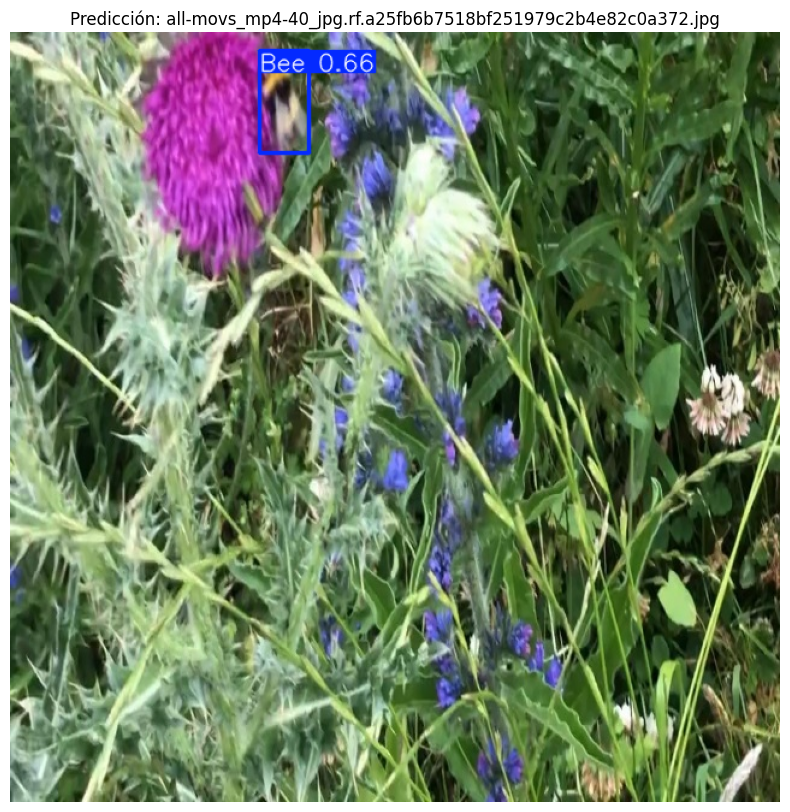

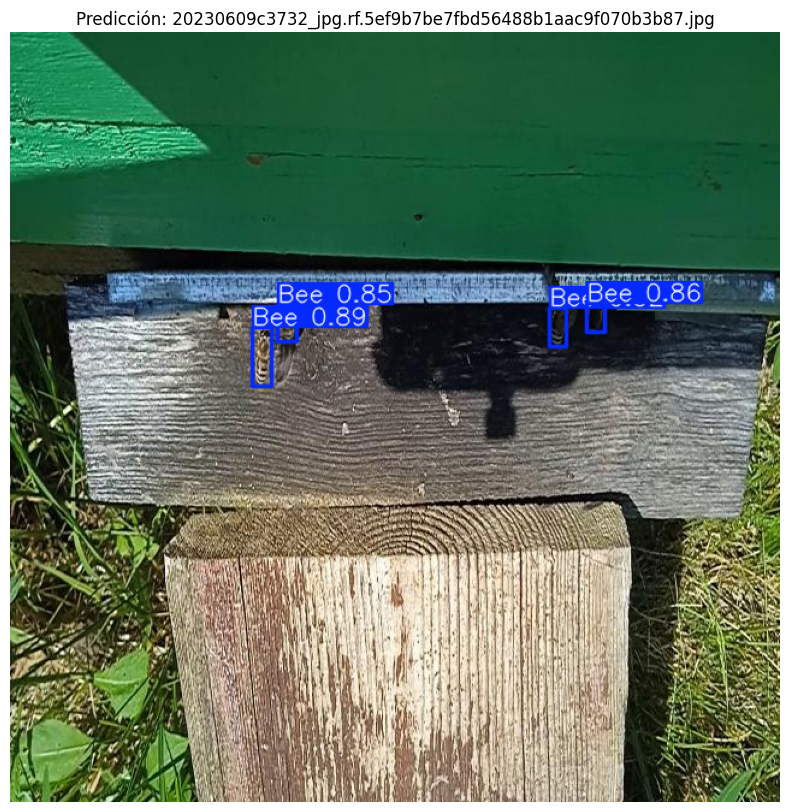

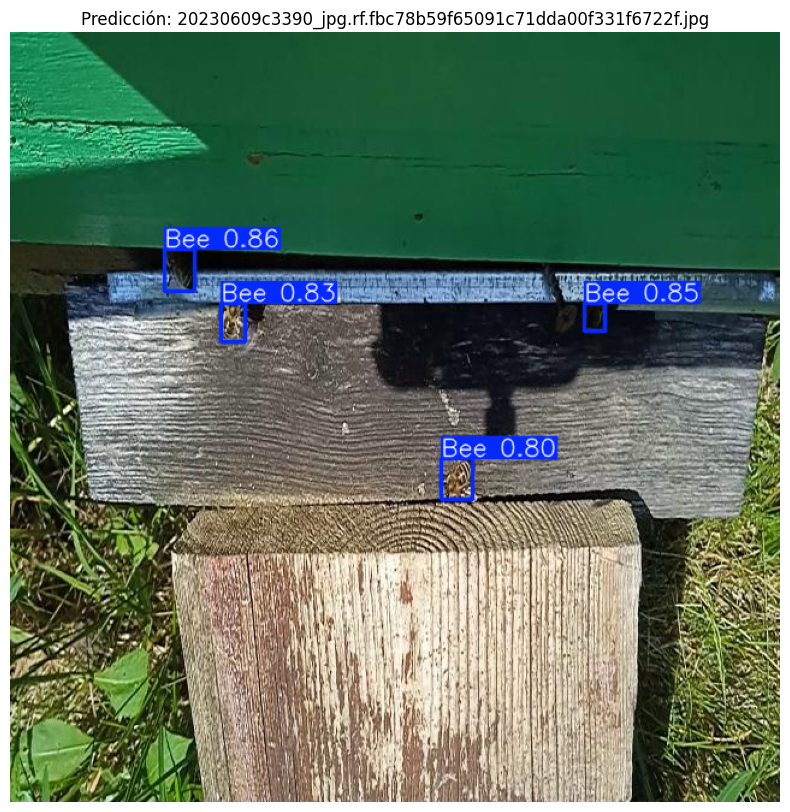

In [ ]:
# Configuración
ruta_imagenes_test = '../data/dataset_mini/test/images/*.jpg'
imagenes = glob.glob(ruta_imagenes_test)
imagenes_a_probar = random.sample(imagenes, 3)

print(f"Probando inferencia en {len(imagenes_a_probar)} imágenes aleatorias...")

for ruta_img in imagenes_a_probar:
    # --- INFERENCIA ---
    results = model.predict(source=ruta_img, conf=0.4, iou=0.5, save=False, verbose=False)

    result = results[0]
    img_con_cajas = result.plot()

    mostrar_imagen(img_con_cajas, f"Predicción: {os.path.basename(ruta_img)}")